In [5]:
# ==========================================================
#                   Universidad Franz Tamayo
# ----------------------------------------------------------
#                        MINERIA DE DATOS
# ----------------------------------------------------------
#        Enrique Alejandro Laurel Cossio, Abr 2026
# ==========================================================
#  H2O AutoML: Automatización del Aprendizaje Automático
# ==========================================================

# H20.ai y AutoML

## Parte 1: Conceptos Fundamentales de H2O y AutoML

### ¿Qué es H2O.ai?
Es una plataforma de Machine Learning de código abierto, diseñada para ser escalable y rápida. A diferencia de otras librerías que corren sobre Python directamente, H2O corre en una **JVM (Java Virtual Machine)**. Esto le permite manejar grandes volúmenes de datos distribuyendo la carga en memoria RAM.

### ¿Qué es H2O AutoML?
Es una función que automatiza el proceso de entrenamiento y ajuste de modelos. En lugar de probar uno por uno, AutoML entrena:
*   Modelos lineales (GLM).
*   Árboles de decisión (XGBoost, GBM, Random Forest).
*   Deep Learning.
*   **Stacked Ensembles:** Combina los mejores modelos anteriores para crear uno superior.

### Ventajas de H2O
1.  **Escalabilidad:** Maneja datasets que superan la memoria RAM mediante compresión eficiente.
2.  **Facilidad:** Con pocas líneas de código obtienes modelos de nivel profesional.
3.  **Producción:** Permite exportar modelos como objetos POJO/MOJO (Java) para usarlos en aplicaciones en tiempo real sin depender de Python.



---

## Parte 2: Configuración del Entorno (El "Engine")

Para que H2O funcione, necesita **Java**. Un error común es tener versiones de Java incompatibles en el sistema. Podemos manejar esto directamente en el entorno de Python usando la librería `jdk4py` o similares, pero lo más robusto es asegurar una versión de Java (8 a 17) y apuntar a ella.

### Instalación de dependencias
```bash
# 1. Asegúrate de estar en tu entorno
conda activate mineria_datos

# 2. Instalación de H2O y gestor de Java para el entorno
pip install h2o
pip install install-jdk

# 3. Instala OpenJDK desde el canal conda-forge
conda install -c conda-forge openjdk=11 -y
```

### Configuración de Java desde Python

In [6]:
#import h2o
#import os
#import sys
#
## Crear una carpeta local donde tengas permisos totales
#path_seguro = os.path.abspath("./h2o_temp")
#if not os.path.exists(path_seguro):
#    os.makedirs(path_seguro)
#
#try:
#    # 'ice_root' es donde H2O escribe sus archivos temporales
#    h2o.init(ice_root=path_seguro
#             #,max_mem_size="4G"
#             )
#except Exception as e:
#    print(f"Error: {e}")

In [3]:
#import os
#import h2o
#
## 1. Localizar la ruta de tu entorno de Conda
## En Windows con Conda, Java suele estar en la carpeta 'Library' del entorno
#if 'CONDA_PREFIX' in os.environ:
#    env_path = os.environ['CONDA_PREFIX']
#    java_home = os.path.join(env_path, 'Library') # Para Windows
#    
#    # 2. Configurar las variables de entorno para esta sesión de Python
#    os.environ['JAVA_HOME'] = java_home
#    os.environ['PATH'] = os.path.join(java_home, 'bin') + os.path.pathsep + os.environ['PATH']
#
## 3. Intentar iniciar de nuevo
#try:
#    h2o.init()
#    print("¡H2O ha vuelto a la vida con éxito!")
#except Exception as e:
#    print(f"Aún no encuentro Java. Error: {e}")

In [4]:
import h2o
import os
import sys

# 1. CONFIGURACIÓN DEL MOTOR (JAVA)
# Buscamos la carpeta del entorno activo de Conda para encontrar su Java
if 'CONDA_PREFIX' in os.environ:
    # En Windows, los binarios de Java instalados por Conda están en Library\bin
    java_home = os.path.join(os.environ['CONDA_PREFIX'], 'Library')
    os.environ['JAVA_HOME'] = java_home
    # Agregamos la ruta al PATH del sistema para que H2O encuentre 'java.exe'
    os.environ['PATH'] = os.path.join(java_home, 'bin') + os.path.pathsep + os.environ['PATH']

# 2. CONFIGURACIÓN DE CARPETAS TEMPORALES (Tu código original)
path_seguro = os.path.abspath("./h2o_temp")
if not os.path.exists(path_seguro):
    os.makedirs(path_seguro)

# 3. INICIO DEL CLUSTER
try:
    # Iniciamos H2O apuntando a la carpeta de temporales segura
    h2o.init(
        ice_root=path_seguro,
        max_mem_size="4G" 
    )
    print("H2O iniciado correctamente con Java del entorno Conda.")
except Exception as e:
    print(f"Error al iniciar H2O: {e}")

Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
; OpenJDK 64-Bit Server VM Zulu11.86+21-CA (build 11.0.30+7-LTS, mixed mode)
  Starting server from C:\Users\ENRIQUE\miniconda3\envs\mineria_datos\Lib\site-packages\h2o\backend\bin\h2o.jar
  Ice root: c:\enrique_D\repositorios_git\MINERIA_DATOS\notebooks_datasets\h2o_temp
  JVM stdout: C:\Users\ENRIQUE\AppData\Local\Temp\tmpdik3nq8c\h2o_ENRIQUE_started_from_python.out
  JVM stderr: C:\Users\ENRIQUE\AppData\Local\Temp\tmpdik3nq8c\h2o_ENRIQUE_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.


H2O_cluster_uptime:,03 secs
H2O_cluster_timezone:,America/La_Paz
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.10
H2O_cluster_version_age:,1 month and 18 days
H2O_cluster_name:,H2O_from_python_ENRIQUE_cfwht4
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,4 Gb
H2O_cluster_total_cores:,8
H2O_cluster_allowed_cores:,8
H2O_cluster_status:,"locked, healthy"


H2O iniciado correctamente con Java del entorno Conda.


## Parte 3: Checklist de Pasos

Para no perderse en el flujo de trabajo, sigan este orden:

1.  **Preparación de datos:** Limpieza y estructuración (CSV, Parquet, etc.).
2.  **Carga a H2O:** Convertir el DataFrame de Pandas a un **H2OFrame**.
3.  **Definición de variables:** Identificar `y` (target) y `x` (predictores).
4.  **Tipos de datos:** Asegurarse de que las variables categóricas sean de tipo `factor`.
5.  **Partición:** Dividir en *Train* y *Test*.
6.  **Configuración de AutoML:** Definir tiempo máximo o número de modelos.
7.  **Entrenamiento:** Ejecutar el proceso.
8.  **Selección:** Revisar el *Leaderboard* y elegir el mejor.
9.  **Evaluación:** Validar con el set de Test usando métricas (AUC, RMSE).
10. **Persistencia:** Guardar el modelo para producción.



## Parte 4: Ejemplo Práctico

### 1. Carga y Preparación

```python
import h2o
from h2o.automl import H2OAutoML

# Cargar datos directamente a un H2OFrame
df = h2o.import_file("https://h2o-public-test-data.s3.amazonaws.com/smalldata/iris/iris_wheader.csv")

# Definir variables
target = "class"
predictors = df.columns
predictors.remove(target)

# IMPORTANTE: Para clasificación, el target DEBE ser factor
df[target] = df[target].asfactor()

# Partición 80% entrenamiento, 20% prueba
train, test = df.split_frame(ratios=[0.8], seed=1234)
```

### 2. Entrenamiento con AutoML
Aquí configuramos los parámetros clave:
*   `max_models`: Cuántos modelos probar.
*   `max_runtime_secs`: Tiempo límite de búsqueda.
*   `stopping_metric`: Qué métrica optimizar (Logloss, AUC, RMSE).

```python
aml = H2OAutoML(max_models=10, seed=1, max_runtime_secs=300, sort_metric="combined_error")
aml.train(x=predictors, y=target, training_frame=train)
```

### 3. El Leaderboard y Selección del Mejor
```python
# Ver los mejores modelos
lb = aml.leaderboard
print(lb.head(rows=lb.nrows)) 

# El mejor modelo se extrae así:
best_model = aml.leader
```

### 4. Evaluación y Métricas
```python
# Evaluar sobre los datos de test que el modelo nunca vio
performance = best_model.model_performance(test)
print(performance)

# Ejemplo de métricas específicas
if best_model.type == "classifier":
    print(f"Confusión Matrix: \n{performance.confusion_matrix()}")
```

### 5. Guardar y Cargar Modelo (Predicción futura)
```python
# Guardar el modelo en una carpeta
model_path = h2o.save_model(model=best_model, path="./my_models", force=True)

# --- En otro script o momento ---
# Cargar el modelo guardado
saved_model = h2o.load_model(model_path)

# Hacer predicciones con nuevos datos
predictions = saved_model.predict(test)
print(predictions.as_data_frame())
```

---

## Consideraciones Finales 
*   **Variables Categóricas:** H2O maneja internamente el One-Hot Encoding, pero si no conviertes la columna a `factor`, el modelo pensará que es una regresión si el target es numérico (0, 1).
*   **Imputación:** H2O maneja valores nulos automáticamente (suelen ir a una categoría aparte o media), pero siempre es mejor que los estudiantes entiendan su data antes.
*   **Sobreajuste (Overfitting):** Explícales que el *Leaderboard* muestra métricas de validación cruzada (Cross-validation), lo que da una idea real de cómo funcionará el modelo con datos nuevos.

# 1. LIBRERIAS Y FUNCIONES

In [7]:
# Cargamos Librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
        
# modelos lineales
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf

# indicadores de ajuste del modelo
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,mean_squared_error,r2_score,confusion_matrix,recall_score,classification_report,precision_score,f1_score
from sklearn.metrics import roc_curve, roc_auc_score

# modelos de árboles de decisión
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import DecisionTreeClassifier

from sklearn.model_selection import GridSearchCV

#librerias para h2o
import h2o
from h2o.automl import H2OAutoML
import jdk
import os

# 3. DATOS

In [8]:
# cargamos datos

ifood_df = pd.read_csv('data/ifood.csv',sep=',', encoding='iso-8859-1')

print(ifood_df.shape) #
ifood_df.head(2)

(2240, 29)


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,5,0,0,0,0,0,0,3,11,0


In [9]:
# una copia a los datos
df = ifood_df.copy()

In [10]:
# Conversión a H2O Frame
hf = h2o.H2OFrame(df)

Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%


In [11]:
# Verificar qué entendió H2O
hf.describe()

Rows:2240
Cols:29

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
type,int,int,enum,enum,int,int,int,time,int,int,int,int,int,int,int,int,int,int,int,int,int,int,int,int,int,int,int,int,int
mins,0.0,1893.0,,,1730.0,0.0,0.0,1343606400000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,11.0,0.0
mean,5592.159821428569,1968.8058035714291,,,52247.251353790605,0.4441964285714278,0.5062499999999995,1373450502857.1462,49.10937499999992,303.93571428571414,26.302232142857132,166.95000000000036,37.52544642857139,27.062946428571482,44.02187499999998,2.325000000000002,4.084821428571437,2.6620535714285793,5.790178571428576,5.316517857142867,0.07276785714285715,0.07455357142857143,0.07276785714285715,0.06428571428571428,0.013392857142857142,0.009375,3.0,11.0,0.14910714285714285
maxs,11191.0,1996.0,,,666666.0,2.0,2.0,1404000000000.0,99.0,1493.0,199.0,1725.0,259.0,263.0,362.0,15.0,27.0,28.0,13.0,20.0,1.0,1.0,1.0,1.0,1.0,1.0,3.0,11.0,1.0
sigma,3246.6621975643416,11.984069456885825,,,25173.076660901414,0.5383980977345934,0.5445382307698761,17463385066.91388,28.96245280837821,336.5973926053719,39.773433764578584,225.7153725117536,54.628979402878095,41.28049848785491,52.1674389149973,1.9322375008559796,2.7787141473881007,2.9231006555397463,3.250958145674428,2.42664500954729,0.25981306992189507,0.2627282848535613,0.25981306992189507,0.24531597433401414,0.1149756062554841,0.09639116794449755,0.0,0.0,0.3562735864084792
zeros,1,0,,,0,1293,1158,0,28,13,400,1,384,419,61,46,49,586,15,11,2077,2073,2077,2096,2210,2219,0,0,1906
missing,0,0,0,0,24,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
0,5524.0,1957.0,Graduation,Single,58138.0,0.0,0.0,2012-09-04 00:00:00,58.0,635.0,88.0,546.0,172.0,88.0,88.0,3.0,8.0,10.0,4.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,11.0,1.0
1,2174.0,1954.0,Graduation,Single,46344.0,1.0,1.0,2014-03-08 00:00:00,38.0,11.0,1.0,6.0,2.0,1.0,6.0,2.0,1.0,1.0,2.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,11.0,0.0
2,4141.0,1965.0,Graduation,Together,71613.0,0.0,0.0,2013-08-21 00:00:00,26.0,426.0,49.0,127.0,111.0,21.0,42.0,1.0,8.0,2.0,10.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,11.0,0.0


## 1. El Arte del Casteo (Casting) en H2O

H2O intenta adivinar el tipo de dato, pero a veces falla. Por ejemplo, si tu variable objetivo es `0` y `1`, H2O la cargará como **numérica**. Si entrenas así, H2O hará una **Regresión** en lugar de una **Clasificación**.

### Tipos de datos comunes en H2O:
*   **Numeric:** Para enteros o decimales (Regresión).
*   **Enum (Factor):** Para categorías o etiquetas (Clasificación).
*   **String:** Texto libre (no se usa para entrenar a menos que se procese).
*   **Time:** Fechas.

### ¿Cómo cambiar los tipos?

```python
# 1. Convertir a Categórica (Factor) - INDISPENSABLE para clasificación
hf['compra'] = hf['compra'].asfactor()
hf['segmento'] = hf['segmento'].asfactor()

# 2. Convertir a Numérico (si se cargó como string por error)
hf['edad'] = hf['edad'].asnumeric()

# 3. Convertir a String
hf['segmento_texto'] = hf['segmento'].ascharacter()

```

---

## 2. ¿Qué pasa si quiero cambiar tipos durante la carga?

Si estás importando un archivo CSV gigante y no quieres cargarlo todo para luego cambiar tipos (lo cual consume el doble de memoria), puedes usar el parámetro `column_types`.

```python
# Definir tipos antes de cargar
tipos = {
    "compra": "enum", 
    "edad": "int", 
    "ingresos": "float64"
}

# Carga optimizada
hf = h2o.import_file("dataset.csv", col_types=tipos)
```

---

## 3. Checklist: Manejo de Datos

Para que no tengan errores de "Model Type Mismatch":

1.  **`h2o.H2OFrame(df_pandas)`**: Carga los datos.
2.  **`hf.types`**: Diccionario que muestra qué tipo asignó H2O a cada columna. **¡Revisar esto siempre!**
3.  **`asfactor()`**: Aplicar a la variable dependiente si el problema es de clasificación.
4.  **`hf.structure()`**: Similar al `info()` de Pandas, para ver una vista previa de los datos transformados.



In [12]:
hf.head(2)

ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
5524,1957,Graduation,Single,58138,0,0,2012-09-04 00:00:00,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
2174,1954,Graduation,Single,46344,1,1,2014-03-08 00:00:00,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0


In [13]:
# casteo 
hf['Response'] = hf['Response'].asfactor()

In [14]:
#hf.summary()
hf.types

{'ID': 'int',
 'Year_Birth': 'int',
 'Education': 'enum',
 'Marital_Status': 'enum',
 'Income': 'int',
 'Kidhome': 'int',
 'Teenhome': 'int',
 'Dt_Customer': 'time',
 'Recency': 'int',
 'MntWines': 'int',
 'MntFruits': 'int',
 'MntMeatProducts': 'int',
 'MntFishProducts': 'int',
 'MntSweetProducts': 'int',
 'MntGoldProds': 'int',
 'NumDealsPurchases': 'int',
 'NumWebPurchases': 'int',
 'NumCatalogPurchases': 'int',
 'NumStorePurchases': 'int',
 'NumWebVisitsMonth': 'int',
 'AcceptedCmp3': 'int',
 'AcceptedCmp4': 'int',
 'AcceptedCmp5': 'int',
 'AcceptedCmp1': 'int',
 'AcceptedCmp2': 'int',
 'Complain': 'int',
 'Z_CostContact': 'int',
 'Z_Revenue': 'int',
 'Response': 'enum'}

In [15]:
# Definir variables
target = "Response"
predictors = ['Kidhome','Recency']

In [16]:
# Partición 80% entrenamiento, 20% prueba
train, test = hf.split_frame(ratios=[0.8], seed=1234)

In [17]:
# autoML
aml = H2OAutoML(max_models=10, seed=1, max_runtime_secs=300, sort_metric="AUC"
                , balance_classes=True   # activa el balanceo de clases
                )
aml.train(x=predictors, y=target, training_frame=train)

AutoML progress: |
14:07:25.583: AutoML: XGBoost is not available; skipping it.

███████████████████████████████████████████████████████████████| (done) 100%


Model Details
=============
H2OGeneralizedLinearEstimator : Generalized Linear Modeling
Model Key: GLM_1_AutoML_1_20260430_140725


GLM Model: summary
    family    link    regularization               lambda_search                                                                  number_of_predictors_total    number_of_active_predictors    number_of_iterations    training_frame
--  --------  ------  ---------------------------  -----------------------------------------------------------------------------  ----------------------------  -----------------------------  ----------------------  -----------------------------------------------
    binomial  logit   Ridge ( lambda = 0.001304 )  nlambda = 30, lambda.max = 6.9111, lambda.min = 0.001304, lambda.1se = 0.1529  2                             2                              33                      AutoML_1_20260430_140725_training_py_4_sid_b484

ModelMetricsBinomialGLM: glm
** Reported on train data. **

MSE: 0.12088499969501196
RMSE: 0.34768520200752284
LogLoss: 0.3981546762044046
AUC: 0.6641535972481344
AUCPR: 0.24305612989509515
Gini: 0.3283071944962688
Null degrees of freedom: 1803
Residual degrees of freedom: 1801
Null deviance: 1516.084995382615
Residual deviance: 1436.5420717454917
AIC: 1442.5420717454917

Confusion Matrix (Act/Pred) for max f1 @ threshold = 0.180865360499246
       0     1    Error    Rate
-----  ----  ---  -------  --------------
0      1107  429  0.2793   (429.0/1536.0)
1      124   144  0.4627   (124.0/268.0)
Total  1231  573  0.3065   (553.0/1804.0)

Maximum Metrics: Maximum metrics at their respective thresholds
metric                       threshold    value     idx
---------------------------  -----------  --------  -----
max f1                       0.180865     0.342449  60
max f2                       0.0909668    0.49979   152
max f0point5                 0.234276     0.289548  27
max accuracy                 0.32602      0.847007  0
max precision                0.304857     0.351351  5
max recall                   0.0566977    1         205
max specificity              0.32602      0.992839  0
max absolute_mcc             0.180865     0.197108  60
max min_per_class_accuracy   0.150166     0.61194   89
max mean_per_class_accuracy  0.179811     0.629246  61
max tns                      0.32602      1525      0
max fns                      0.32602      265       0
max fps                      0.032078     1536      229
max tps                      0.0566977    268       205
max tnr                      0.32602      0.992839  0
max fnr                      0.32602      0.988806  0
max fpr                      0.032078     1         229
max tpr                      0.0566977    1         205

Gains/Lift Table: Avg response rate: 14,86 %, avg score: 14,86 %
group    cumulative_data_fraction    lower_threshold    lift      cumulative_lift    response_rate    score      cumulative_response_rate    cumulative_score    capture_rate    cumulative_capture_rate    gain      cumulative_gain    kolmogorov_smirnov
-------  --------------------------  -----------------  --------  -----------------  ---------------  ---------  --------------------------  ------------------  --------------  -------------------------  --------  -----------------  --------------------
1        0.0149667                   0.321727           2.24378   2.24378            0.333333         0.323953   0.333333                    0.323953            0.0335821       0.0335821                  124.378   124.378            0.0218633
2        0.0232816                   0.317463           1.79502   2.08351            0.266667         0.317463   0.309524                    0.321635            0.0149254       0.0485075                  79.5025   108.351            0.0296273
3        0.0338137                   0.31323            2.47997   2.207              0.368421         0.31323    0.327869                    0.319017            0.0261194       0.0746269                  147.997   120.7  

In [18]:
# Ver los mejores modelos
lb = aml.leaderboard
print(lb.head(rows=lb.nrows)) 

# El mejor modelo se extrae así:
model_rank = 1  # 1 = primer modelo, 2 = segundo, 3 = tercero
lb_df = lb.as_data_frame()
selected_model_id = lb_df.loc[model_rank - 1, "model_id"]
best_model = h2o.get_model(selected_model_id)
print(f"Seleccionado modelo #{model_rank}: {selected_model_id}")

model_id                                                      auc    logloss     aucpr    mean_per_class_error      rmse       mse
GLM_1_AutoML_1_20260430_140725                           0.661847   0.39895   0.239916                0.373985  0.347942  0.121064
GBM_1_AutoML_1_20260430_140725                           0.657881   0.40051   0.239009                0.372542  0.348507  0.121457
StackedEnsemble_BestOfFamily_1_AutoML_1_20260430_140725  0.656893   0.400195  0.240715                0.384741  0.348349  0.121347
StackedEnsemble_AllModels_1_AutoML_1_20260430_140725     0.654154   0.401882  0.223775                0.378615  0.349414  0.12209
XRT_1_AutoML_1_20260430_140725                           0.632698   0.416761  0.230737                0.394998  0.352374  0.124167
GBM_2_AutoML_1_20260430_140725                           0.629314   0.408235  0.217781                0.390664  0.351064  0.123246
GBM_grid_1_AutoML_1_20260430_140725_model_1              0.628723   0.412067  0.2118

c:\Users\ENRIQUE\miniconda3\envs\mineria_datos\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


In [19]:
best_model._model_json['output']['coefficients_table']

names,coefficients,standardized_coefficients
Intercept,-0.7262408,-1.8726078
Kidhome,-0.3992637,-0.2159737
Recency,-0.0196064,-0.5682452


In [55]:
## Mostrar coeficientes y estadísticas
#coef_table = best_model.coef_table()
#print(coef_table)

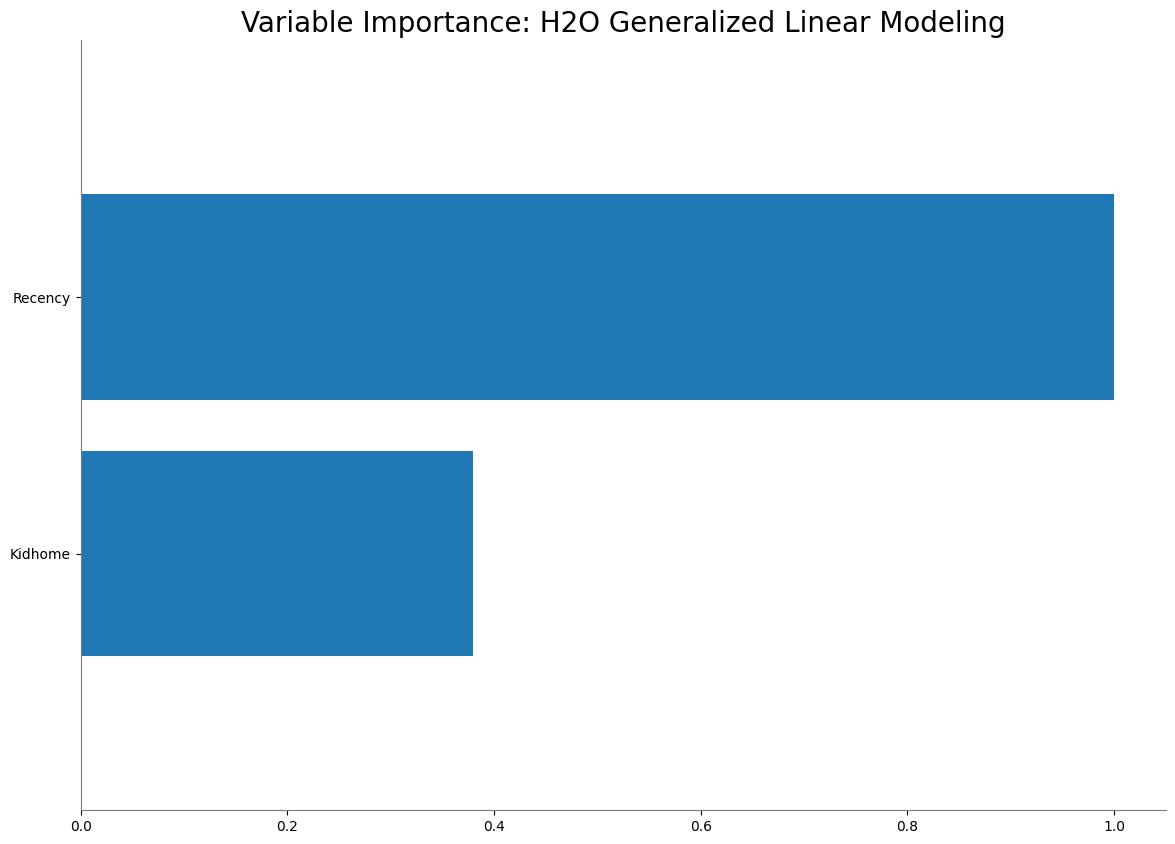

<Figure size 640x480 with 0 Axes>

In [20]:
# importancia de variables
best_model.varimp_plot()

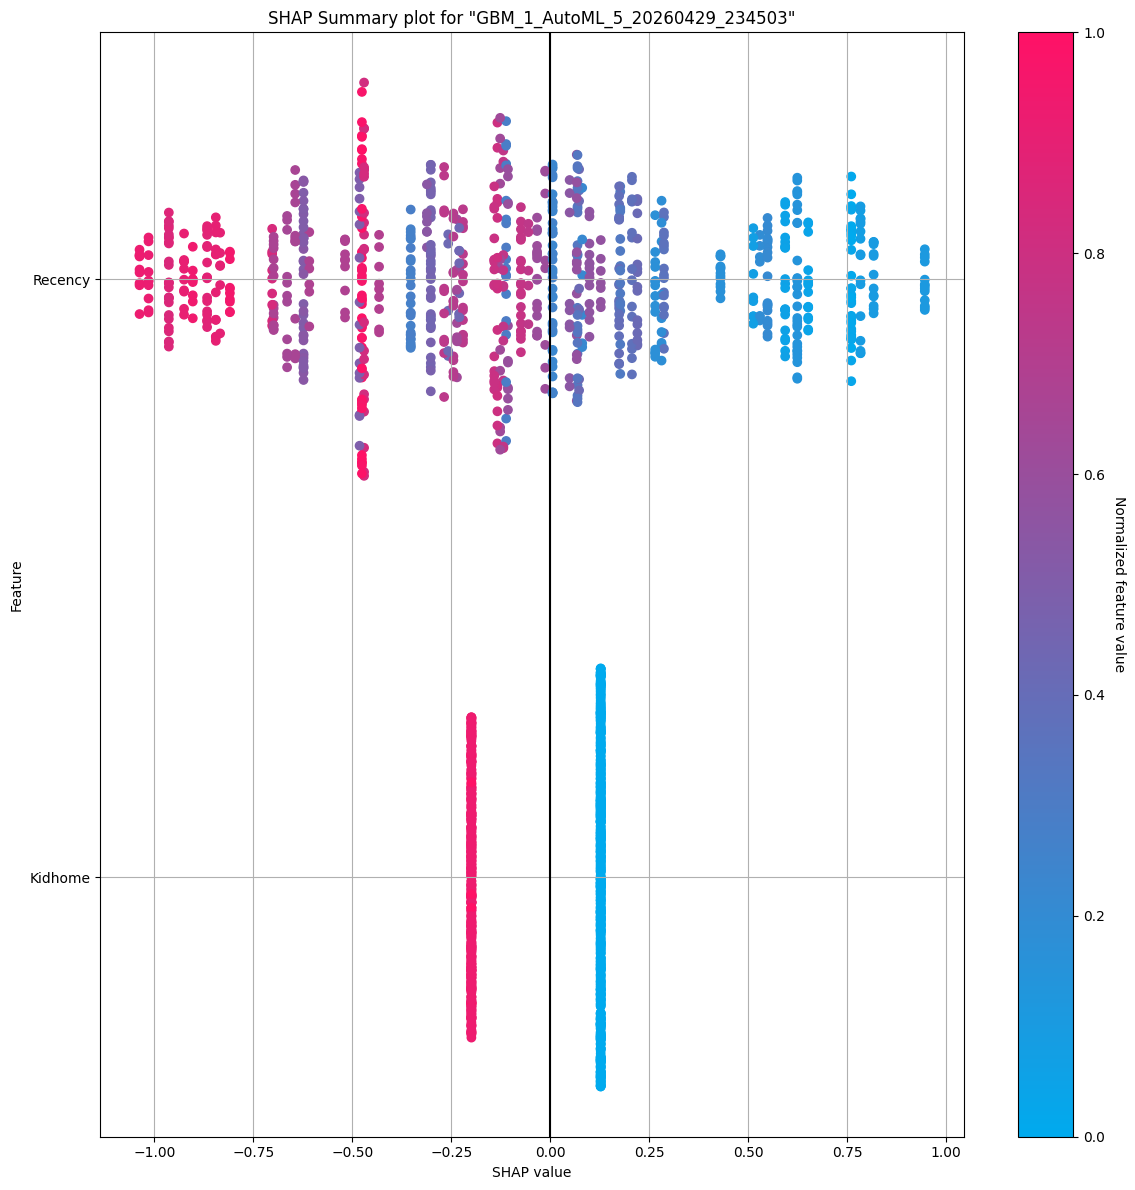

In [45]:
# 4. Generar el gráfico de SHAP values
# shap_summary_plot muestra la importancia de cada variable

best_model.shap_summary_plot(hf[predictors])

📊 Lectura del gráfico
Eje Y (variables): aparecen dos variables: Recency y Kidhome.

Eje X (SHAP value): indica cuánto contribuye cada variable a aumentar o disminuir la predicción del modelo.

Valores positivos → empujan la predicción hacia la clase positiva (ej. mayor probabilidad de “1”).

Valores negativos → empujan hacia la clase negativa (ej. mayor probabilidad de “0”).

Colores: representan el valor real de la variable en cada observación.

Azul = valores bajos.

Rojo = valores altos.

In [21]:
# Evaluar sobre los datos de test que el modelo nunca vio
performance = best_model.model_performance(test)
print(performance)

# Ejemplo de métricas específicas
if best_model.type == "classifier":
    print(f"Confusión Matrix: \n{performance.confusion_matrix()}")

ModelMetricsBinomialGLM: glm
** Reported on test data. **

MSE: 0.12178310502758945
RMSE: 0.348974361561977
LogLoss: 0.39597205320058987
AUC: 0.6965397215397217
AUCPR: 0.24238141010955855
Gini: 0.3930794430794433
Null degrees of freedom: 435
Residual degrees of freedom: 433
Null deviance: 370.70460537181276
Residual deviance: 345.2876303909144
AIC: 351.2876303909144

Confusion Matrix (Act/Pred) for max f1 @ threshold = 0.16580376394023957
       0    1    Error    Rate
-----  ---  ---  -------  -------------
0      242  128  0.3459   (128.0/370.0)
1      21   45   0.3182   (21.0/66.0)
Total  263  173  0.3417   (149.0/436.0)

Maximum Metrics: Maximum metrics at their respective thresholds
metric                       threshold    value     idx
---------------------------  -----------  --------  -----
max f1                       0.165804     0.376569  67
max f2                       0.117092     0.554493  103
max f0point5                 0.179811     0.303951  57
max accuracy           

In [27]:
# 4. Obtener desempeño
perf = best_model.model_performance(test)

# Extraer el umbral que maximiza el F1 score (o usa 'f1' si prefieres ese balance)
best_threshold = perf.find_threshold_by_max_metric("f1")

# 5. Imprimir Matriz de Confusión usando ESE umbral específico
print(f"Matriz de Confusión (Umbral optimizado para F1 score: {best_threshold}):")
print(perf.confusion_matrix(thresholds=[best_threshold]))
    
# 6. Imprimir el valor de F1 score exacto para ese umbral
# .f1() devuelve una lista de [umbral, valor], extraemos el valor
acc_value = perf.f1(thresholds=[best_threshold])[0][1]
print(f"F1 score coincidente: {acc_value}")

Matriz de Confusión (Umbral optimizado para F1 score: 0.16580376394023957):
Confusion Matrix (Act/Pred) @ threshold = 0.16580376394023957
       0    1    Error    Rate
-----  ---  ---  -------  -------------
0      242  128  0.3459   (128.0/370.0)
1      21   45   0.3182   (21.0/66.0)
Total  263  173  0.3417   (149.0/436.0)
F1 score coincidente: 0.658256880733945


In [30]:
# 6. Accuracy usando el umbral definido antes
print("Accuracy (threshold):", perf.accuracy(thresholds=[best_threshold])[0][1])

# 7. Precision, Recall, F1 usando el mismo umbral
print("Precision (threshold):", perf.precision(thresholds=[best_threshold])[0][1])
print("Recall (threshold):", perf.recall(thresholds=[best_threshold])[0][1])
#print("F1 (threshold):", perf.f1(thresholds=[best_threshold])[0][1])

# 8. Otras métricas útiles
print("AUC:", perf.auc())        # para clasificación binaria
print("LogLoss:", perf.logloss()) # para clasificación
#print("RMSE:", perf.rmse())       # para regresión
#print("MAE:", perf.mae())         # para regresión

Accuracy (threshold): 0.658256880733945
Precision (threshold): 0.26011560693641617
Recall (threshold): 0.6818181818181818
AUC: 0.6965397215397217
LogLoss: 0.39597205320058987


In [64]:
# Guardar el modelo en una carpeta
model_path = h2o.save_model(model=best_model, path="./my_models", force=True)

# --- En otro script o momento ---
# Cargar el modelo guardado
saved_model = h2o.load_model(model_path)

# Hacer predicciones con nuevos datos
predictions = saved_model.predict(test)
print(predictions.as_data_frame())

glm prediction progress: |███████████████████████████████████████████████████████| (done) 100%
     predict        p0        p1
0          0  0.836890  0.163110
1          0  0.921198  0.078802
2          1  0.813252  0.186748
3          1  0.753686  0.246314
4          0  0.924869  0.075131
..       ...       ...       ...
431        0  0.851419  0.148581
432        0  0.945363  0.054637
433        0  0.900595  0.099405
434        0  0.892668  0.107332
435        0  0.924869  0.075131

[436 rows x 3 columns]


c:\Users\ENRIQUE\miniconda3\envs\mineria_datos\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


In [ ]:
h2o.cluster().shutdown()